Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🤖 Starting Hyperparameter Tuning...
------------------------------------------------------------
Tuning Linear Regression...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
  ✅ Best Params: {}
  ✅ Best Score (RMSE): 14.13

Tuning SVR...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
  ✅ Best Params: {'C': 100, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}
  ✅ Best Score (RMSE): 14.55

Tuning KNN...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  ✅ Best Params: {'n_neighbors': 11, 'weights': 'distance'}
  ✅ Best Score (RMSE): 16.67

Tuning Random Forest...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
  ✅ Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
  ✅ Best Score (RMSE): 15.09

Tuning Gradient Boosting...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  ✅ Be

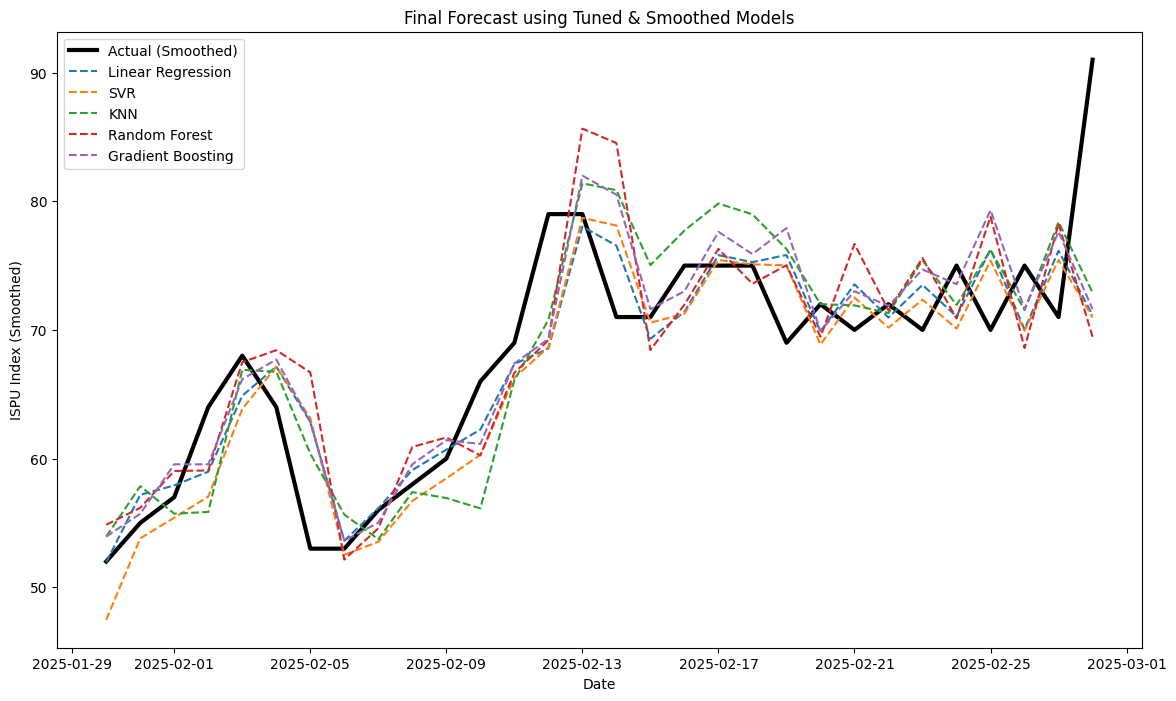

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from google.colab import drive

# 1. Data Cleaning dan Preparation
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/DataMining/ispu_dki_all.csv')

# Basic Cleanup
df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')  # Ubah format teks menjadi tanggal
df['max'] = df['max'].replace(0, np.nan) # Anggap nilai 0 sebagai data hilang (NaN)

# A. Hilangkan outlier persentil ke-99
upper_limit = df['max'].quantile(0.99)
df['max'] = df['max'].clip(upper=upper_limit)

# B. Interpolasi (perbaiki celah pada data)
daily_ispu = df.groupby('tanggal')['max'].mean().asfreq('D').interpolate(method='linear')
data = pd.DataFrame(daily_ispu)
data.columns = ['y']

# C. Smoothing dengan filter median untuk menghilangkan noise
data['y'] = data['y'].rolling(window=3, center=True, min_periods=1).median()

# D. Feature Engineering
data['lag_1'] = data['y'].shift(1)
data['lag_2'] = data['y'].shift(2)
data['lag_7'] = data['y'].shift(7)
data['rolling_mean_7'] = data['y'].shift(1).rolling(window=7).mean()

# Fitur tanggal siklis
data['month_sin'] = np.sin(2 * np.pi * data.index.month / 12)
data['month_cos'] = np.cos(2 * np.pi * data.index.month / 12)

data = data.dropna()

# ==========================================
# 2. Pemisahan dan Penskalaan
# ==========================================
train_size = int(len(data) - 30)
X = data.drop('y', axis=1)
y = data['y']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

# ==========================================
# 3. Definisikan Grid Tuning
# ==========================================
model_params = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },
    "SVR": {
        "model": SVR(),
        "params": {
            'kernel': ['rbf'],
            'C': [1, 10, 50, 100],
            'gamma': ['scale', 0.1],
            'epsilon': [0.1, 0.2]
        }
    },
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance']
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            'n_estimators': [100],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            'n_estimators': [100],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5]
        }
    }
}

# ==========================================
# 4. Jalankan tuning
# ==========================================
tscv = TimeSeriesSplit(n_splits=3)
best_models = {}

print("🤖 Starting Hyperparameter Tuning...")
print("-" * 60)

for name, config in model_params.items():
    print(f"Tuning {name}...")

    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_scaled, y)
    best_models[name] = grid.best_estimator_
    print(f"  ✅ Best Params: {grid.best_params_}")
    print(f"  ✅ Best Score (RMSE): {np.sqrt(-grid.best_score_):.2f}\n")

# ==========================================
# 5. Hasil Pengujian & Evaluasi Akhir
# ==========================================
X_train_final = X_scaled.iloc[:train_size]
X_test_final = X_scaled.iloc[train_size:]
y_train_final = y.iloc[:train_size]
y_test_final = y.iloc[train_size:]

print("================ FINAL RESULTS (Smoothed Data) ================")
print(f"{'Model':<25} | {'MSE':<10} | {'MAE':<10} | {'RMSE':<10} | {'MAPE':<10}")
print("-" * 80)

plt.figure(figsize=(14, 8))
plt.plot(y_test_final.index, y_test_final, label='Actual (Smoothed)', color='black', linewidth=3)

for name, model in best_models.items():
    # Latih ulang pada semua data latih yang tersedia
    model.fit(X_train_final, y_train_final)
    preds = model.predict(X_test_final)

    # Hitung semua metrik
    mse = mean_squared_error(y_test_final, preds)
    mae = mean_absolute_error(y_test_final, preds)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test_final, preds)

    # Print row
    print(f"{name:<25} | {mse:<10.2f} | {mae:<10.2f} | {rmse:<10.2f} | {mape:<10.2%}")

    # Tambahkan ke plot
    plt.plot(y_test_final.index, preds, label=name, linestyle='--')

plt.title('Final Forecast using Tuned & Smoothed Models')
plt.ylabel('ISPU Index (Smoothed)')
plt.xlabel('Date')
plt.legend()
plt.show()